In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/dataset/LengthOfStay.csv'
df = pd.read_csv(file_path)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 400)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid
0,1,8/29/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B
1,2,5/26/2012,5+,F,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A
2,3,9/22/2012,1,F,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B
3,4,8/9/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A
4,5,12/20/2012,0,F,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E


Drop columns that are not necessary, eid is unique ID number which is not helping with any prediction.

In [ ]:
# List of columns to drop
cols_to_drop = ['eid']

# Dropping the columns
df = df.drop(columns=cols_to_drop)

# Display the new list of columns to confirm
print("Remaining columns for the model:")
print(df.columns.tolist())

Remaining columns for the model:
['vdate', 'rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'discharged', 'facid']


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   vdate                       100000 non-null  object 
 1   rcount                      100000 non-null  object 
 2   gender                      99986 non-null   object 
 3   dialysisrenalendstage       100000 non-null  int64  
 4   asthma                      100000 non-null  int64  
 5   irondef                     100000 non-null  int64  
 6   pneum                       100000 non-null  int64  
 7   substancedependence         100000 non-null  int64  
 8   psychologicaldisordermajor  100000 non-null  int64  
 9   depress                     100000 non-null  int64  
 10  psychother                  100000 non-null  int64  
 11  fibrosisandother            100000 non-null  int64  
 12  malnutrition                100000 non-null  int64  
 13  hemo           

,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,99991.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.036420,0.035270,0.094940,0.039450,0.063060,0.239040,0.051660,0.049390,0.004790,0.049480,0.080000,11.975939,10.177455,137.891433,141.963384,14.097185,1.099350,29.805759,73.444720,6.493768,2.123310
std,0.187334,0.184462,0.293134,0.194664,0.243072,0.426499,0.221341,0.216682,0.069044,0.216869,0.271295,2.031792,5.353131,2.999598,29.992996,12.952454,0.200262,2.003769,11.644555,0.568473,2.050641
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.400000,0.100000,124.912632,-1.005927,1.000000,0.219770,21.992683,21.000000,0.200000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.900000,7.700000,135.871048,121.682383,11.000000,0.964720,28.454235,66.000000,6.500000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.900000,9.400000,137.887337,142.088545,12.000000,1.098764,29.807516,73.000000,6.500000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.900000,11.500000,139.912886,162.180996,14.000000,1.234867,31.156885,81.000000,6.500000,3.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.100000,245.900000,151.387283,271.444277,682.500000,2.035202,38.935293,130.000000,10.000000,10.000000


_Find null columns - missing values_


In [ ]:
# 1. Sodium (Numerical): Fill with Median
sodium_median = df['sodium'].median()
df['sodium'] = df['sodium'].fillna(sodium_median)

# 2. Gender (Categorical): Fill with Most Frequent (Mode)
# [0] is used because .mode() returns a Series
gender_mode = df['gender'].mode()[0]
df['gender'] = df['gender'].fillna(gender_mode)

# 3. Verify the fix
print(f"Missing values in Sodium: {df['sodium'].isnull().sum()}")
print(f"Missing values in Gender: {df['gender'].isnull().sum()}")
print(f"Used Median for Sodium: {sodium_median}")
print(f"Used Mode for Gender: {gender_mode}")

Missing values in Sodium: 0
Missing values in Gender: 0
Used Median for Sodium: 137.8873374
Used Mode for Gender: F


Assign the property of each column to be either categorical, numerical or binary.

In [ ]:
# 1. Continuous Measurements (The "True" Numerical Columns)
numerical_cols = [
    'rcount',
    'hematocrit',
    'neutrophils',
    'sodium',
    'glucose',
    'bloodureanitro',
    'creatinine',
    'bmi',
    'pulse',
    'respiration',
    'secondarydiagnosisnonicd9'
]

# 2. Binary/Flag Columns (0 or 1)
binary_cols = [
    'dialysisrenalendstage',
    'asthma',
    'irondef',
    'pneum',
    'substancedependence',
    'psychologicaldisordermajor',
    'depress',
    'psychother',
    'fibrosisandother',
    'malnutrition',
    'hemo'
]

# 3. Categorical Columns
categorical_cols=['gender', 'facid']

Make sure each column is holding the type of data we want

In [ ]:
df.dtypes

,0
vdate,object
rcount,object
gender,object
dialysisrenalendstage,int64
asthma,int64
irondef,int64
pneum,int64
substancedependence,int64
psychologicaldisordermajor,int64
depress,int64


In [ ]:
df['rcount'].unique()

array(['0', '5+', '1', '3', '4', '2'], dtype=object)

In [ ]:
# Replace '5+' with '5' and convert the column to integer
df['rcount'] = df['rcount'].replace('5+', '5').astype(int)

Check whether there are similar responses that can be grouped into a single category.

In [ ]:
for x in categorical_cols:
  print(df[x].unique())

['F' 'M']
['B' 'A' 'E' 'D' 'C']


In [ ]:
for x in categorical_cols:
  df[x] = df[x].astype('category')

In [ ]:
df.dtypes

,0
vdate,object
rcount,int64
gender,category
dialysisrenalendstage,int64
asthma,int64
irondef,int64
pneum,int64
substancedependence,int64
psychologicaldisordermajor,int64
depress,int64


Check and remove if there are duplicated rows

In [ ]:
num_duplicates=df.duplicated().sum()
print(f"Total duplicate rows to remove: {num_duplicates}")

Total duplicate rows to remove: 0


Check if there is negative value in numerical_cols which is illogical

In [ ]:
# List of columns where 0 is allowed (Counts)
valid_zero_cols = ['rcount', 'secondarydiagnosisnonicd9']

# Create the check list by filtering those out
check_cols = [col for col in numerical_cols if col not in valid_zero_cols]

for x in check_cols:
  if not df[df[x]<=0].empty:
    print(df[df[x]<=0])

            vdate  rcount gender  dialysisrenalendstage  asthma  irondef  pneum  substancedependence  psychologicaldisordermajor  depress  psychother  fibrosisandother  malnutrition  hemo  hematocrit  neutrophils      sodium   glucose  bloodureanitro  creatinine        bmi  pulse  respiration  secondarydiagnosisnonicd9 discharged facid
59774  11/27/2012       4      M                      0       0        0      0                    0                           0        0           0                 0             0     0        11.9          9.4  137.517491 -1.005927            12.0    0.703748  28.503134     82          6.5                          1  12/4/2012     A


Glucose with negative values is totally abnormal, it may be key in error. Drop that row for accuracy.

In [ ]:
print("Number of rows with negative glucose:",len(df[df['glucose']<0]))
df=df[df['glucose']>0]
print("Number of rows with negative glucose value after removed:",len(df[df['glucose']<0]))

Number of rows with negative glucose: 1
Number of rows with negative glucose value after removed: 0


Handle noise in numerical columns using zscore:

We will categorize a value as outlier as long as the absolute z-score is more than 3 and we will drop that row for accuracy.

In [ ]:
df[numerical_cols].describe()

,rcount,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9
count,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
mean,1.118181,11.975939,10.177463,137.891436,141.964814,14.097206,1.099354,29.805772,73.444634,6.493768,2.123321
std,1.542939,2.031802,5.353157,2.999478,29.989738,12.952517,0.200259,2.003775,11.644582,0.568476,2.050648
min,0.000000,4.400000,0.100000,124.912632,11.047504,1.000000,0.219770,21.992683,21.000000,0.200000,0.000000
25%,0.000000,10.900000,7.700000,135.871197,121.682777,11.000000,0.964723,28.454212,66.000000,6.500000,1.000000
50%,0.000000,11.900000,9.400000,137.887337,142.090192,12.000000,1.098764,29.807538,73.000000,6.500000,1.000000
75%,2.000000,12.900000,11.500000,139.912772,162.181066,14.000000,1.234869,31.156903,81.000000,6.500000,3.000000
max,5.000000,24.100000,245.900000,151.387283,271.444277,682.500000,2.035202,38.935293,130.000000,10.000000,10.000000


In [ ]:
#detect noise in the dataset
from scipy.stats import zscore
for x in numerical_cols:
  scaler = zscore(df[x])
  outliers = df[np.abs(scaler) > 3]
  print(f"Number of Z-Score outliers in {x}: {len(outliers)}")

Number of Z-Score outliers in rcount: 0
Number of Z-Score outliers in hematocrit: 1113
Number of Z-Score outliers in neutrophils: 791
Number of Z-Score outliers in sodium: 285
Number of Z-Score outliers in glucose: 277
Number of Z-Score outliers in bloodureanitro: 1025
Number of Z-Score outliers in creatinine: 245
Number of Z-Score outliers in bmi: 289
Number of Z-Score outliers in pulse: 274
Number of Z-Score outliers in respiration: 2273
Number of Z-Score outliers in secondarydiagnosisnonicd9: 2050


In [ ]:
print(f"Original shape: {df.shape}")
#drop the row
df = df[(np.abs(zscore(df[numerical_cols])) < 3).all(axis=1)]
print(f"New shape after dropping outliers: {df.shape}")

Original shape: (99999, 26)
New shape after dropping outliers: (91877, 26)


In [ ]:
df[numerical_cols].describe()

,rcount,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9
count,91877.000000,91877.000000,91877.000000,91877.000000,91877.000000,91877.000000,91877.000000,91877.000000,91877.000000,91877.000000,91877.000000
mean,1.118659,11.911269,9.914496,137.891550,141.973443,13.249255,1.099532,29.804379,73.430902,6.499740,1.967108
std,1.542413,1.843720,3.679186,2.959033,29.560742,6.203151,0.197792,1.975384,11.480542,0.463569,1.765130
min,0.000000,5.900000,0.100000,128.912734,52.261383,1.000000,0.498844,23.802439,39.000000,4.800000,0.000000
25%,0.000000,11.000000,7.700000,135.877497,121.728197,11.000000,0.965148,28.460724,66.000000,6.500000,1.000000
50%,0.000000,11.900000,9.400000,137.888291,142.103885,12.000000,1.098797,29.806618,73.000000,6.500000,1.000000
75%,2.000000,12.800000,11.300000,139.907883,162.135032,13.000000,1.234929,31.153215,81.000000,6.500000,3.000000
max,5.000000,18.050000,26.200000,146.887794,231.642468,52.500000,1.699959,35.814905,108.000000,8.150000,8.000000


# ***DATA TRANSFORMATION***

Data binning / generalization with BMI column

Why Binning? "Continuous BMI had too much noise (e.g., 28.1 vs 28.2). Binning groups similar patients together to find stronger patterns."

Why 10 Bins? "Standard medical bins put 99% of our patients into just two groups ('Overweight' and 'Obese'), which gave the model no useful information. Using 10 statistical bins forced the data into equal groups, revealing the difference between 'Low-Risk' and 'High-Risk' patients."

In [ ]:
import pandas as pd

# Create the 10 Bins (Scores 1-10)
df['bmi_Score'] = pd.qcut(df['bmi'], q=10, labels=False) + 1

# We group by the Score, then look at the original 'bmi' column
range_table = df.groupby('bmi_Score')['bmi'].agg(['min', 'max', 'count'])

# Rename columns
range_table.columns = ['Min BMI', 'Max BMI', 'Patient Count']

# Print the result
print("--- BMI Score Ranges (Quantile Binning) ---")
print(range_table)

--- BMI Score Ranges (Quantile Binning) ---
             Min BMI    Max BMI  Patient Count
bmi_Score                                     
1          23.802439  27.252161           9188
2          27.252257  28.128871           9188
3          28.129090  28.752118           9187
4          28.752319  29.306479           9188
5          29.306661  29.806618           9188
6          29.806620  30.302118           9187
7          30.302254  30.844494           9188
8          30.844509  31.479768           9187
9          31.479889  32.358706           9188
10         32.358921  35.814905           9188


In [ ]:
df.head()

,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,bmi_Score
0,8/29/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,7
1,5/26/2012,5,F,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,3
2,9/22/2012,1,F,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,4
3,8/9/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,2
4,12/20/2012,0,F,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,6


Feature Engineering (Data Aggregation)

In [ ]:
df['vdate'] = pd.to_datetime(df['vdate'])
df['discharged'] = pd.to_datetime(df['discharged'])

#calculate which month is the admission date
df['month_num'] = df['vdate'].dt.month

#calculate length of hospital stay
df['lengthofstay'] = df['discharged'] - df['vdate']
df['lengthofstay'] = df['lengthofstay'].dt.days

#calculate sum of comorbidity counts
df['comorbidity_count'] = df[binary_cols].sum(axis=1)

numerical_cols.append('month_num')
numerical_cols.append('comorbidity_count')
df.head()

,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,bmi_Score,month_num,lengthofstay,comorbidity_count
0,2012-08-29,0,F,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,2012-09-01,B,7,8,3,0
1,2012-05-26,5,F,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,2012-06-02,A,3,5,7,0
2,2012-09-22,1,F,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,2012-09-25,B,4,9,3,0
3,2012-08-09,0,F,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,2012-08-10,A,2,8,1,0
4,2012-12-20,0,F,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,2012-12-24,E,6,12,4,2


_Data transformation -  normalization_

In [ ]:
from sklearn.preprocessing import StandardScaler , MinMaxScaler
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

scaler_cols=[c for c in numerical_cols]

for col in scaler_cols:
  # 1. Z-score Standardization (Creates 'col_Standardized')
  df[f'{col}_Standardized'] = scaler_standard.fit_transform(df[[col]])

  # 2. Min-Max Normalization (Creates 'col_Normalized')
  df[f'{col}_Normalized'] = scaler_minmax.fit_transform(df[[col]])

# Show a sneak peek of the results
print("\n--- Example: Glucose Columns ---")
print(df[['glucose', 'glucose_Standardized', 'glucose_Normalized']].head())


--- Example: Glucose Columns ---
      glucose  glucose_Standardized  glucose_Normalized
0  192.476918              1.708474            0.781663
1   94.078507             -1.620230            0.233119
2  130.530524             -0.387101            0.436329
3  163.377028              0.724058            0.619439
4   94.886654             -1.592891            0.237624


We decided to use only MinMaxScaler() which is the _Normalized column, so we will drop original column and _Standardized column.

We selected Min-Max Normalization (and removed the original/standardized versions) to unify all numerical features onto a common [0, 1] scale.

In the original dataset, features had vast scale disparities (e.g., glucose ranges up to 200, while creatinine is ~1.0). This made direct visual comparison impossible. Normalizing the data allows us to effectively interpret and compare feature distributions in our plots (such as boxplots and histograms) without the larger values visually dominating the smaller ones.

In [ ]:
cols_to_drop = []

for col in scaler_cols:
  cols_to_drop.append(col)           # Drop Original
  cols_to_drop.append(f'{col}_Standardized')  # Drop Standardized

# Execute the drop
df_final = df.drop(columns=cols_to_drop)

print("Final Data Shape:", df_final.shape)
print("Columns left:", df_final.columns.tolist())

Final Data Shape: (91877, 30)
Columns left: ['vdate', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'discharged', 'facid', 'bmi_Score', 'lengthofstay', 'rcount_Normalized', 'hematocrit_Normalized', 'neutrophils_Normalized', 'sodium_Normalized', 'glucose_Normalized', 'bloodureanitro_Normalized', 'creatinine_Normalized', 'bmi_Normalized', 'pulse_Normalized', 'respiration_Normalized', 'secondarydiagnosisnonicd9_Normalized', 'month_num_Normalized', 'comorbidity_count_Normalized']


In [ ]:
df_final.head()

,vdate,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,discharged,facid,bmi_Score,lengthofstay,rcount_Normalized,hematocrit_Normalized,neutrophils_Normalized,sodium_Normalized,glucose_Normalized,bloodureanitro_Normalized,creatinine_Normalized,bmi_Normalized,pulse_Normalized,respiration_Normalized,secondarydiagnosisnonicd9_Normalized,month_num_Normalized,comorbidity_count_Normalized
0,2012-08-29,F,0,0,0,0,0,0,0,0,0,0,0,2012-09-01,B,7,3,0.0,0.460905,0.540230,0.636905,0.781663,0.213592,0.742542,0.551925,0.826087,0.507463,0.500,0.636364,0.000000
1,2012-05-26,F,0,0,0,0,0,0,0,0,0,0,0,2012-06-02,A,3,7,1.0,0.255144,0.153257,0.434989,0.233119,0.135922,0.369924,0.387770,0.318841,0.507463,0.125,0.363636,0.000000
2,2012-09-22,F,0,0,0,0,0,0,0,0,0,0,0,2012-09-25,B,4,3,0.2,0.205761,0.337165,0.230641,0.436329,0.213592,0.471984,0.419678,0.362319,0.507463,0.250,0.727273,0.000000
3,2012-08-09,F,0,0,0,0,0,0,0,0,0,0,0,2012-08-10,A,2,1,0.0,0.493827,0.356322,0.560849,0.619439,0.213592,0.339700,0.346021,0.536232,0.507463,0.125,0.636364,0.000000
4,2012-12-20,F,0,0,0,1,0,1,0,0,0,0,0,2012-12-24,E,6,4,0.0,0.263374,0.342912,0.540866,0.237624,0.203883,0.619433,0.537482,0.405797,0.238806,0.250,1.000000,0.222222


Why other data transformation are not necessary?

- Data Integration: This step is not applicable because our project utilizes a single, self-contained dataset (LengthOfStay.csv) and does not require merging information from multiple external sources or databases.

- Data Generalization: Aside from BMI, we avoid generalization because replacing precise clinical measurements (like glucose or pulse) with broad categories causes a loss of information that reduces the Decision Tree's ability to accurately predict the exact number of days.

# ***EDA - Univariate***

# ***Numerical Variables:***

- What is the distribution of Length of Stay?

- What is the frequency of Prior Readmissions (rcount)? (How many patients are "frequent flyers" vs. new patients?)

--- Length of Stay Statistics ---
Range: 1 to 17 days
Mean: 3.92 days
Median: 4.00 days
Skewness: 0.62


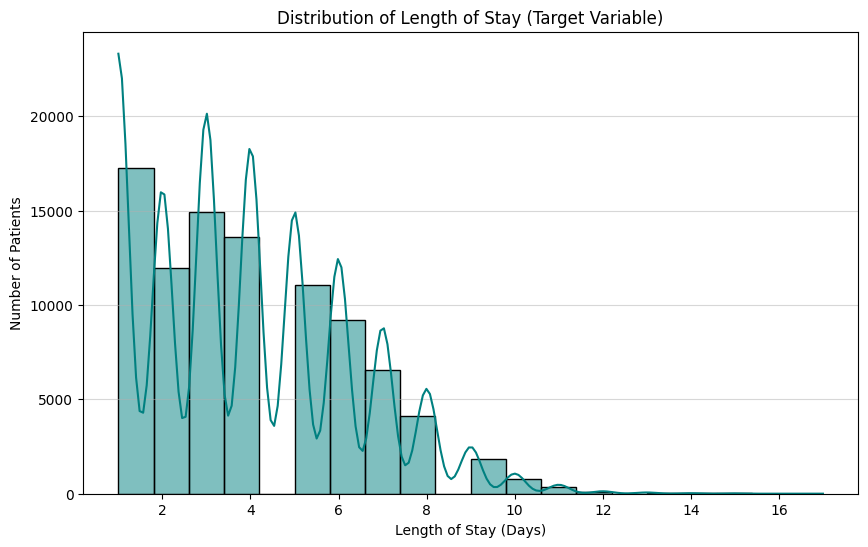

In [ ]:
# 1. What is the distribution of Length of Stay?
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Calculate Statistics ---
mean_los = df['lengthofstay'].mean()
median_los = df['lengthofstay'].median()
min_los = df['lengthofstay'].min()
max_los = df['lengthofstay'].max()
skew_los = df['lengthofstay'].skew()

print(f"--- Length of Stay Statistics ---")
print(f"Range: {min_los} to {max_los} days")
print(f"Mean: {mean_los:.2f} days")
print(f"Median: {median_los:.2f} days")
print(f"Skewness: {skew_los:.2f}")

# --- 2. Visualization ---
plt.figure(figsize=(10, 6))
sns.histplot(df['lengthofstay'], bins=20, kde=True, color='teal')

plt.title('Distribution of Length of Stay (Target Variable)')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Number of Patients')
plt.grid(axis='y', alpha=0.5)
plt.show()

--- Prior Readmissions Distribution ---
        Count  Percentage
rcount                   
0       50515        55.0
1       13825        15.0
2        9186        10.0
3        7382         8.0
4        6409         7.0
5        4560         5.0


/tmp/ipython-input-1340123974.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='rcount', data=df, palette='magma')


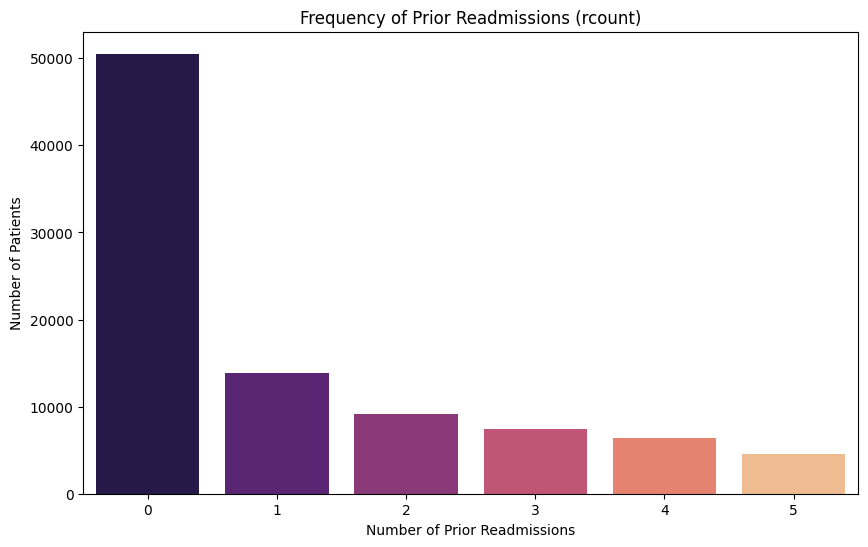

In [ ]:
# 2. What is the frequency of Prior Readmissions (rcount)?
counts = df['rcount'].value_counts().sort_index()
percents = df['rcount'].value_counts(normalize=True).sort_index() * 100

print("--- Prior Readmissions Distribution ---")
print(pd.DataFrame({'Count': counts, 'Percentage': percents.round(1)}))

# --- Visualization ---
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='rcount', data=df, palette='magma')

plt.title('Frequency of Prior Readmissions (rcount)')
plt.xlabel('Number of Prior Readmissions')
plt.ylabel('Number of Patients')

plt.show()

# ***Categorical Variables:***

- What is the gender propotion in this dataset?

--- Gender Proportion ---
        Count  Percentage
gender                   
F       53474        58.2
M       38403        41.8


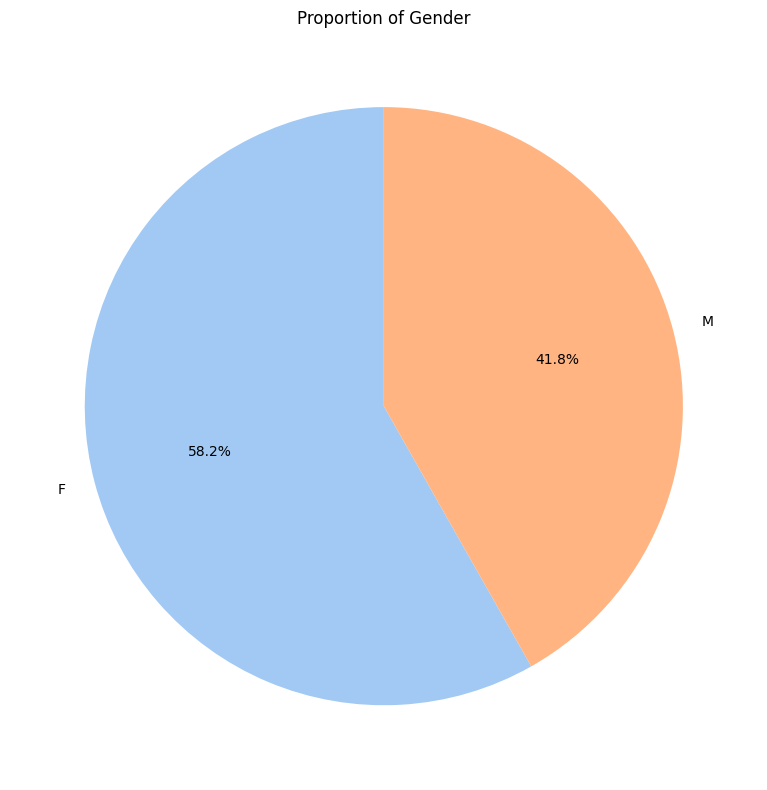

In [ ]:
# --- 1. Gender Proportion ---
gender_counts = df['gender'].value_counts()
gender_percents = df['gender'].value_counts(normalize=True) * 100

print("--- Gender Proportion ---")
print(pd.DataFrame({'Count': gender_counts, 'Percentage': gender_percents.round(1)}))

# --- Visualization ---
plt.figure(figsize=(8,8))

# Plot 1: Gender (Pie Chart for proportion)
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'), startangle=90)
plt.title('Proportion of Gender')

plt.tight_layout()
plt.show()

# ***EDA - Bivariate & Correlation***

# *Numerical vs. Numerical:*

- Which numerical features correlate most strongly with Length of Stay?

- How does the frequency of Prior Readmissions (rcount) impact the current Length of Stay?

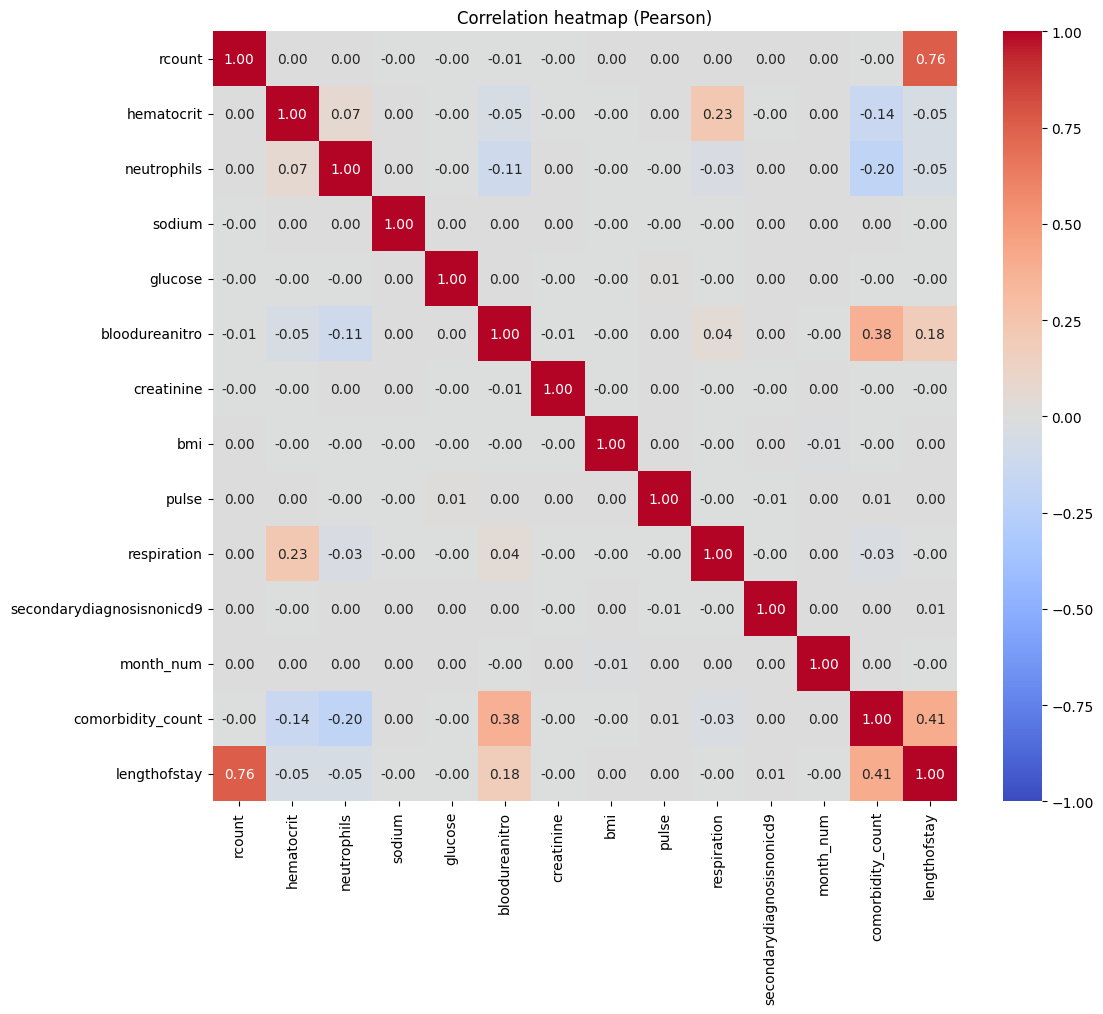

--- Correlation with Length of Stay ---
lengthofstay                 1.000000
rcount                       0.762208
comorbidity_count            0.406243
bloodureanitro               0.175375
secondarydiagnosisnonicd9    0.005858
pulse                        0.004164
bmi                          0.000005
glucose                     -0.000271
month_num                   -0.000502
sodium                      -0.002616
respiration                 -0.003413
creatinine                  -0.004976
neutrophils                 -0.047800
hematocrit                  -0.054546
Name: lengthofstay, dtype: float64


,rcount,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,month_num,comorbidity_count,lengthofstay
rcount,1.000000,0.000079,0.003412,-0.002582,-0.000785,-0.007289,-0.004470,0.000552,0.003636,0.002122,0.004728,0.001424,-0.004411,0.762208
hematocrit,0.000079,1.000000,0.069795,0.001936,-0.002824,-0.052471,-0.001882,-0.004872,0.000920,0.225294,-0.000675,0.001860,-0.141733,-0.054546
neutrophils,0.003412,0.069795,1.000000,0.002841,-0.000588,-0.108805,0.001653,-0.000973,-0.002141,-0.033192,0.000996,0.000004,-0.201131,-0.047800
sodium,-0.002582,0.001936,0.002841,1.000000,0.001649,0.000924,0.001862,-0.001199,-0.003321,-0.003658,0.000926,0.004849,0.000341,-0.002616
glucose,-0.000785,-0.002824,-0.000588,0.001649,1.000000,0.002007,-0.002612,-0.000787,0.007934,-0.003107,0.001760,0.002465,-0.000493,-0.000271
bloodureanitro,-0.007289,-0.052471,-0.108805,0.000924,0.002007,1.000000,-0.005347,-0.004095,0.004856,0.039516,0.000496,-0.000885,0.382540,0.175375
creatinine,-0.004470,-0.001882,0.001653,0.001862,-0.002612,-0.005347,1.000000,-0.004434,0.000110,-0.002782,-0.003127,0.002533,-0.004401,-0.004976
bmi,0.000552,-0.004872,-0.000973,-0.001199,-0.000787,-0.004095,-0.004434,1.000000,0.000354,-0.002834,0.000976,-0.009526,-0.001074,0.000005
pulse,0.003636,0.000920,-0.002141,-0.003321,0.007934,0.004856,0.000110,0.000354,1.000000,-0.003215,-0.006488,0.000115,0.007485,0.004164
respiration,0.002122,0.225294,-0.033192,-0.003658,-0.003107,0.039516,-0.002782,-0.002834,-0.003215,1.000000,-0.000942,0.000104,-0.026293,-0.003413


In [ ]:
#We use Pearson correlation and heatmap for question 1
cols_to_plot = numerical_cols.copy()
if 'lengthofstay' not in cols_to_plot:
  cols_to_plot.append('lengthofstay')

# Filter the dataframe to just these columns
df_num = df[cols_to_plot].copy()

# Correlation matrix (Pearson)
corr = df_num.corr(numeric_only=True)

# Create Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,)

plt.title("Correlation heatmap (Pearson)")
plt.show()

# Display the correlation values
print("--- Correlation with Length of Stay ---")
print(corr['lengthofstay'].sort_values(ascending=False))

# Display full table
corr

--- Statistical Validation (Pearson Correlation) ---
rcount vs lengthofstay: r=0.762, p=0.000e+00, n=91877
Result: Statistically Significant Correlation.


/tmp/ipython-input-3698228743.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rcount', y='lengthofstay', data=df, palette='viridis')


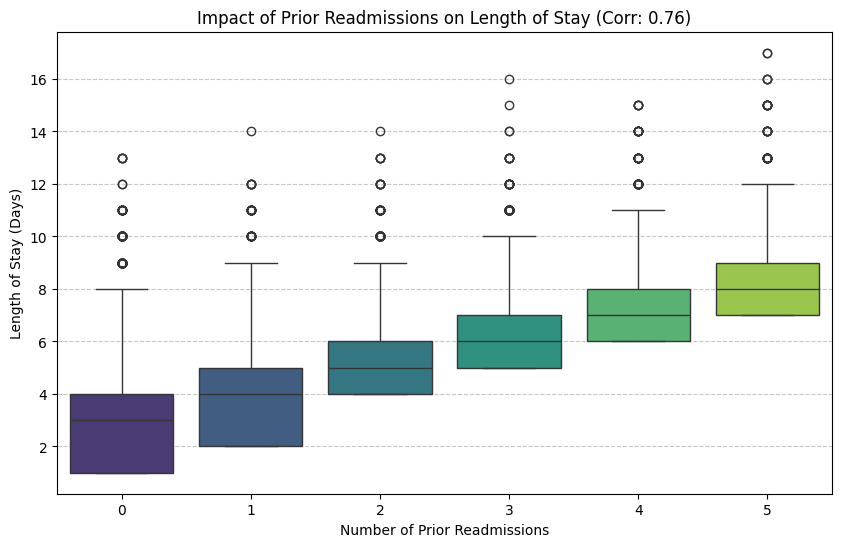

In [ ]:
from scipy import stats

def corr_with_pvalue(x, y):
  # Builds a temporary table with both columns and removes rows where either x or y is missing.
  d = pd.DataFrame({"x": x, "y": y}).dropna()

  # If fewer than 3 valid pairs remain, correlation is unreliable/undefined → return NaN
  if len(d) < 3:
      return np.nan, np.nan, len(d)

  r, p = stats.pearsonr(d["x"], d["y"])
  return r, p, len(d)

# --- APPLY IT TO QUESTION 3 ---
#Question 3: How does the frequency of Prior Readmissions (rcount) impact the current Length of Stay?
pairs = [("rcount", "lengthofstay")]

print("--- Statistical Validation (Pearson Correlation) ---")
for a, b in pairs:
  if a in df.columns and b in df.columns:
    r, p, n = corr_with_pvalue(df[a], df[b])
    print(f"{a} vs {b}: r={r:.3f}, p={p:.3e}, n={n}")

    # Add interpretation for the report
    if p < 0.05:
      print("Result: Statistically Significant Correlation.")
    else:
      print("Result: Not Significant.")

# --- THE VISUALIZATION (Boxplot) ---
plt.figure(figsize=(10, 6))

# Boxplot: Shows the median and range of Stay for each Readmission Count
sns.boxplot(x='rcount', y='lengthofstay', data=df, palette='viridis')

# Update title dynamically if we calculated r
plt.title(f'Impact of Prior Readmissions on Length of Stay (Corr: {r:.2f})')
plt.xlabel('Number of Prior Readmissions')
plt.ylabel('Length of Stay (Days)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# ***t-test: Numeric VS Two Groups from Categorical:***

- Is there a significant difference in Length of Stay between Male and Female patients?

In [ ]:
from scipy import stats

# Prepare a clean subset for Gender t-test
# We'll compare Female vs Male
if "gender" in df.columns and "lengthofstay" in df.columns:
  # Filter for only 'F' and 'M' (just in case there are other labels)
  df_tt = df[df["gender"].isin(["F", "M"])][["gender", "lengthofstay"]].dropna()

  # Split Length of Stay into two separate groups
  g1 = df_tt[df_tt["gender"] == "F"]["lengthofstay"]
  g2 = df_tt[df_tt["gender"] == "M"]["lengthofstay"]

  # Print sample size and mean for each group (descriptive stats)
  print("--- Gender Comparison ---")
  print("n(Female) =", len(g1), " mean =", g1.mean())
  print("n(Male)   =", len(g2), " mean =", g2.mean())

  # Run Welch’s two-sample t-test
  t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
  # equal_var=False means Welch’s t-test, which handles unequal variances

  # Output results
  print("Welch t-test: t =", t_stat, " p =", p_val)

  # Quick interpretation logic
  if p_val < 0.05:
      print("Result: Significant Difference")
  else:
      print("Result: No Significant Difference")
else:
    print("Required columns missing: gender and/or lengthofstay")

--- Gender Comparison ---
n(Female) = 53474  mean = 3.7972659610277892
n(Male)   = 38403  mean = 4.099835950316382
Welch t-test: t = -19.465171498161478  p = 3.357313256752016e-84
Result: Significant Difference


In [ ]:
def cohens_d(a, b):
  # Removes missing values from both groups so calculations are clean
  a = a.dropna()
  b = b.dropna()
  na, nb = len(a), len(b)

  # Checks sample sizes. If either group has fewer than 2 values, variance can’t be computed reliably → return NaN
  if na < 2 or nb < 2:
      return np.nan

  sa2 = a.var(ddof=1)
  sb2 = b.var(ddof=1)

  # Computes sample variances of each group (ddof=1 makes it sample variance)
  sp = np.sqrt(((na - 1)*sa2 + (nb - 1)*sb2) / (na + nb - 2))

  # Computes the pooled standard deviation sp. This is a weighted average of the two group variances (weighted by sample sizes), then square-rooted.
  return (a.mean() - b.mean()) / sp # Returns Cohen’s d: It measures the mean difference in standard deviation units.

# --- Run Analysis for Gender ---
if "gender" in df.columns and "lengthofstay" in df.columns:
  # 1. Re-create the groups (just to be safe/standalone)
  df_tt = df[df["gender"].isin(["F", "M"])][["gender", "lengthofstay"]].dropna()
  g1 = df_tt[df_tt["gender"] == "F"]["lengthofstay"]
  g2 = df_tt[df_tt["gender"] == "M"]["lengthofstay"]

  # 2. Calculate Cohen's d
  d = cohens_d(g1, g2)
  print(f"Cohen's d (Female - Male): {d:.4f}")

  # 3. Automatic Interpretation (Standard Rules of Thumb)
  abs_d = abs(d)
  print("\n--- Interpretation ---")
  if abs_d < 0.2:
      print("Effect Size: Negligible (The difference is trivial/meaningless).")
  elif abs_d < 0.5:
      print("Effect Size: Small (There is a difference, but it is subtle).")
  elif abs_d < 0.8:
      print("Effect Size: Medium (The difference is noticeable).")
  else:
      print("Effect Size: Large (The groups are very different).")

else:
  print("Required columns missing: gender and/or lengthofstay")

Cohen's d (Female - Male): -0.1304

--- Interpretation ---
Effect Size: Negligible (The difference is trivial/meaningless).


Visualizing Gender Difference...


/tmp/ipython-input-1018295694.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=target, data=df, palette="Set2")


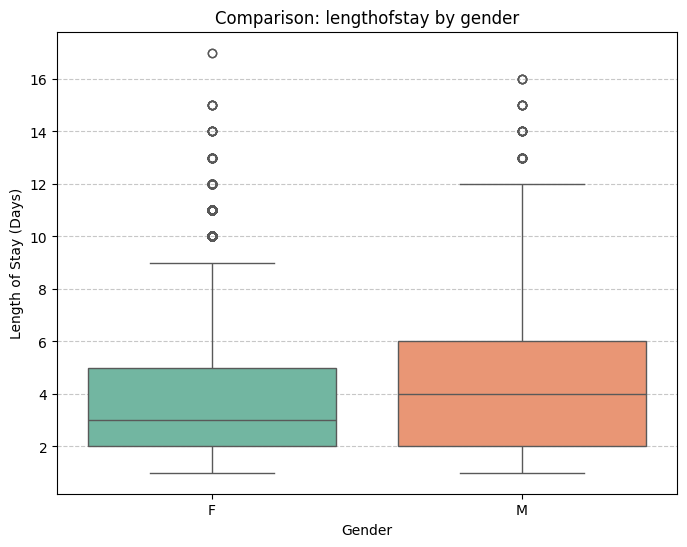

In [ ]:
# --- Function to Plot T-Test Results ---
def plot_ttest_visual(df, cat_col, target='lengthofstay'):
  plt.figure(figsize=(8, 6))

  # Draw the Boxplot
  # x = The Category (e.g., Gender), y = The Target (Length of Stay)
  sns.boxplot(x=cat_col, y=target, data=df, palette="Set2")

  # Add titles and labels
  plt.title(f'Comparison: {target} by {cat_col}')
  plt.ylabel('Length of Stay (Days)')
  plt.xlabel(cat_col.capitalize()) # Capitalize the label
  plt.grid(axis='y', linestyle='--', alpha=0.7)

  plt.show()

# --- Generate the Plots ---
# Gender Comparison
if 'gender' in df.columns:
  print("Visualizing Gender Difference...")
  plot_ttest_visual(df, 'gender')

# ***ANOVA (Numeric vs 3+ groups)***

- Does the admission month significantly affect the Length of Stay?

- Does the comorbidity count (number of medical conditions) significantly affect the Length of Stay?

Groups used (Months): [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
ANOVA Result: F = 0.65, p = 0.7848713881964577
RESULT: Not Significant (Month has no effect on Length of Stay).


/tmp/ipython-input-2975576761.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_aov, x='month_name', y=target_col, palette="Blues", order=month_map.values())


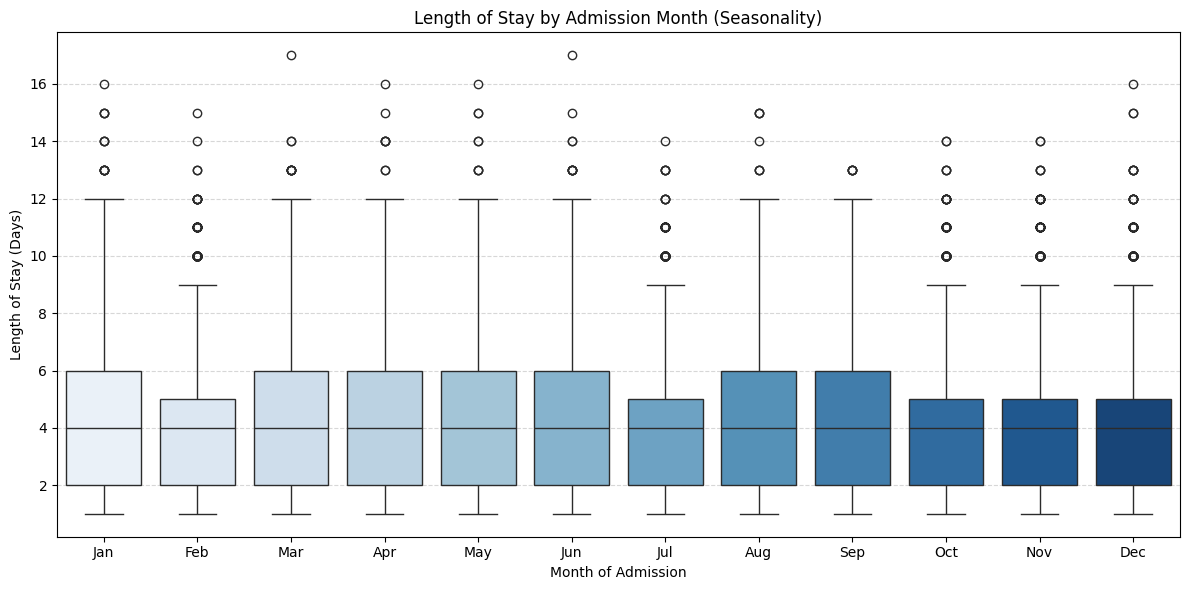

In [ ]:
#Length of stay by Admission Month
# We use the column 'month_num' that we extract when feature engineering as our group
group_col = "month_num"
target_col = "lengthofstay"

# Proceed only if required columns exist
if group_col in df.columns and target_col in df.columns:

    df_aov = df[[group_col, target_col]].dropna()

    # Identify Groups (Months 1-12)
    # We explicitly sort them so the graph runs Jan -> Dec, not by random count
    keep = sorted(df_aov[group_col].unique())

    # Prepare Data for ANOVA (List of lists)
    groups = [df_aov[df_aov[group_col] == g][target_col] for g in keep]

    # Perform ANOVA
    # F-statistic: Are the differences between months bigger than the differences inside months?
    f_stat, p_val = stats.f_oneway(*groups)

    print(f"Groups used (Months): {list(keep)}")
    print(f"ANOVA Result: F = {f_stat:.2f}, p = {p_val}")

    # Interpretation for Report
    if p_val < 0.05:
        print("RESULT: Significant Difference (Length of Stay varies significantly by Month).")
        print(" -> This confirms Seasonality should be included in the model.")
    else:
        print("RESULT: Not Significant (Month has no effect on Length of Stay).")

    # Visualization: Boxplot
    plt.figure(figsize=(12, 6))

    # We map 1-12 to names for a professional look
    month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
    df_aov['month_name'] = df_aov['month_num'].map(month_map)

    # Plot using the ordered names
    sns.boxplot(data=df_aov, x='month_name', y=target_col, palette="Blues", order=month_map.values())

    plt.title("Length of Stay by Admission Month (Seasonality)")
    plt.xlabel("Month of Admission")
    plt.ylabel("Length of Stay (Days)")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    print(f"Required columns missing: {group_col} and/or {target_col}")

Groups used (Count of Diseases): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
ANOVA Result: F = 2610.17, p = 0.0
RESULT: Significant Difference (Sicker patients have different stay durations).
 -> This confirms Comorbidity Count is a strong predictor.


/tmp/ipython-input-35098252.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_aov, x=group_col, y=target_col, palette="Reds")


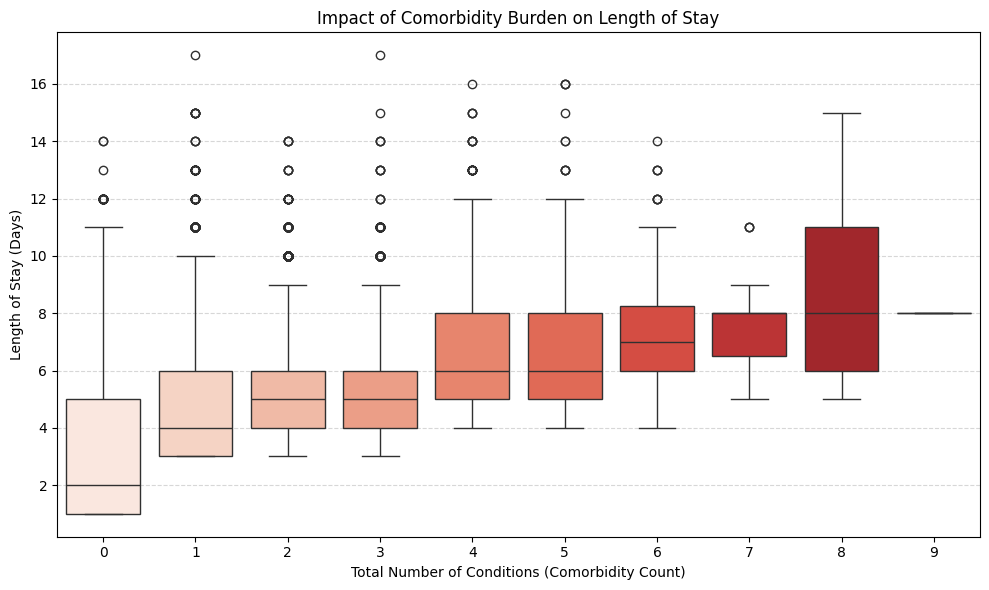

In [ ]:
#length of stay by number of medical conditions (comordity counts)

group_col = "comorbidity_count"
target_col = "lengthofstay"

if group_col in df.columns and target_col in df.columns:

    df_aov = df[[group_col, target_col]].dropna()

    # Identify Groups (0 diseases, 1 disease, 2 diseases...)
    keep = sorted(df_aov[group_col].unique())

    # Prepare Data
    groups = [df_aov[df_aov[group_col] == g][target_col] for g in keep]

    # Perform ANOVA
    f_stat, p_val = stats.f_oneway(*groups)

    print(f"Groups used (Count of Diseases): {list(keep)}")
    print(f"ANOVA Result: F = {f_stat:.2f}, p = {p_val}")

    # Interpretation
    if p_val < 0.05:
        print("RESULT: Significant Difference (Sicker patients have different stay durations).")
        print(" -> This confirms Comorbidity Count is a strong predictor.")
    else:
        print("RESULT: Not Significant.")

    # Visualization: Boxplot
    plt.figure(figsize=(10, 6))

    # Use a gradient red palette (Light Red = Healthy, Dark Red = Sick)
    sns.boxplot(data=df_aov, x=group_col, y=target_col, palette="Reds")

    plt.title("Impact of Comorbidity Burden on Length of Stay")
    plt.xlabel("Total Number of Conditions (Comorbidity Count)")
    plt.ylabel("Length of Stay (Days)")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    print(f"Required columns missing: {group_col} and/or {target_col}")

# ***Model Select: Decision Tree Regressor***

While Linear Regression provides a useful baseline, we selected the Decision Tree Regressor to better capture the non-linear, 'step-wise' impact of prior readmissions (rcount) and to automatically detect interactions between clinical vitals

# ***Train/Test Split***

We split the data:

Train (80%): used to learn the model

Test (20%): held out for final evaluation

In [ ]:
from sklearn.model_selection import train_test_split

# Define target group
target = 'lengthofstay'

# Drop rows where target is missing
df_model = df_final.dropna(subset=[target]).copy()

# Separate features and target
# We combine all three lists into X
numerical_cols_norm = [col + "_Normalized" for col in numerical_cols if col != 'bmi']
numerical_cols_norm
categorical_cols.append('bmi_Score')
X = df_model[numerical_cols_norm + categorical_cols + binary_cols]
y = df_model[target]

# Perform the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Output the shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Features included: {len(X.columns)}")

X_train shape: (73501, 26)
X_test shape: (18376, 26)
Features included: 26


# ***Build a preprocessing + Decision Tree pipeline***

Why a pipeline?
- One-hot encoding: convert categories to numbers for the model
- Decision Tree Regressor: fits non-linear decision rules

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer

# Define the transformer
numerical_transformer = Pipeline(steps=[
  ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
  ("imputer", SimpleImputer(strategy="most_frequent")),
  ("onehot", OneHotEncoder(handle_unknown="ignore", drop='first'))
])

# Build the ColumnTransformer
# We "passthrough" binary features since they don't need changes
preprocess = ColumnTransformer(
  transformers=[
    ("num", numerical_transformer, numerical_cols_norm),
    ("bin", "passthrough", binary_cols),
    ("cat", categorical_transformer, categorical_cols),
  ]
)

# Define the Decision Tree Regressor
tree = DecisionTreeRegressor(
  random_state=42
)

# Combine into a single Pipeline
model = Pipeline(steps=[
  ("preprocess", preprocess),
  ("tree", tree)
])

# Display the model structure
model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['rcount_Normalized',
                                                   'hematocrit_Normalized',
                                                   'neutrophils_Normalized',
                                                   'sodium_Normalized',
                                                   'glucose_Normalized',
                                                   'bloodureanitro_Normalized',
                                                   'creatinine_Normalized',
                                                   'pulse_Normalized',
                                                   'respiration_Normalized',
                                                   'secondaryd...
                                                   'asthma', 'irondef', 'pneum',
                                                   'substancedependence',
                                                   'psychologicaldisordermajor',
                                                   'depress', 'psychother',
                                                   'fibrosisandother',
                                                   'malnutrition', 'hemo']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'facid',
                                                   'bmi_Score'])])),
                ('tree', DecisionTreeRegressor(random_state=42))])

# ***Baseline vs Decision Tree***
Before a “smart” model, always compare to a baseline.

Baseline: predict mean salary of training set for everyone.

In [ ]:
#Baseline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Baseline predictor
y_pred_baseline = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

mae_base = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = mean_squared_error(y_test, y_pred_baseline) #, squared=False)
r2_base = r2_score(y_test, y_pred_baseline)

print("Baseline (mean prediction)")
print("MAE :", round(mae_base, 2))
print("RMSE:", round(rmse_base, 2))
print("R^2 :", round(r2_base, 4))

Baseline (mean prediction)
MAE : 1.91
RMSE: 5.48
R^2 : -0.0


In [ ]:
# Fit decision tree
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) #, squared=False)
r2 = r2_score(y_test, y_pred)

print("Decision Tree Regressor")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R^2 :", round(r2, 4))

Decision Tree Regressor
MAE : 0.46
RMSE: 0.73
R^2 : 0.8659


The Decision Tree Regressor significantly outperforms the Baseline model, reducing the average error from 1.91 days to just 0.48 days and improving the $R^2$ score from 0.0 to 0.8478, proving it is a highly effective tool for predicting hospital stay duration.

# ***Visualize a shallow tree***

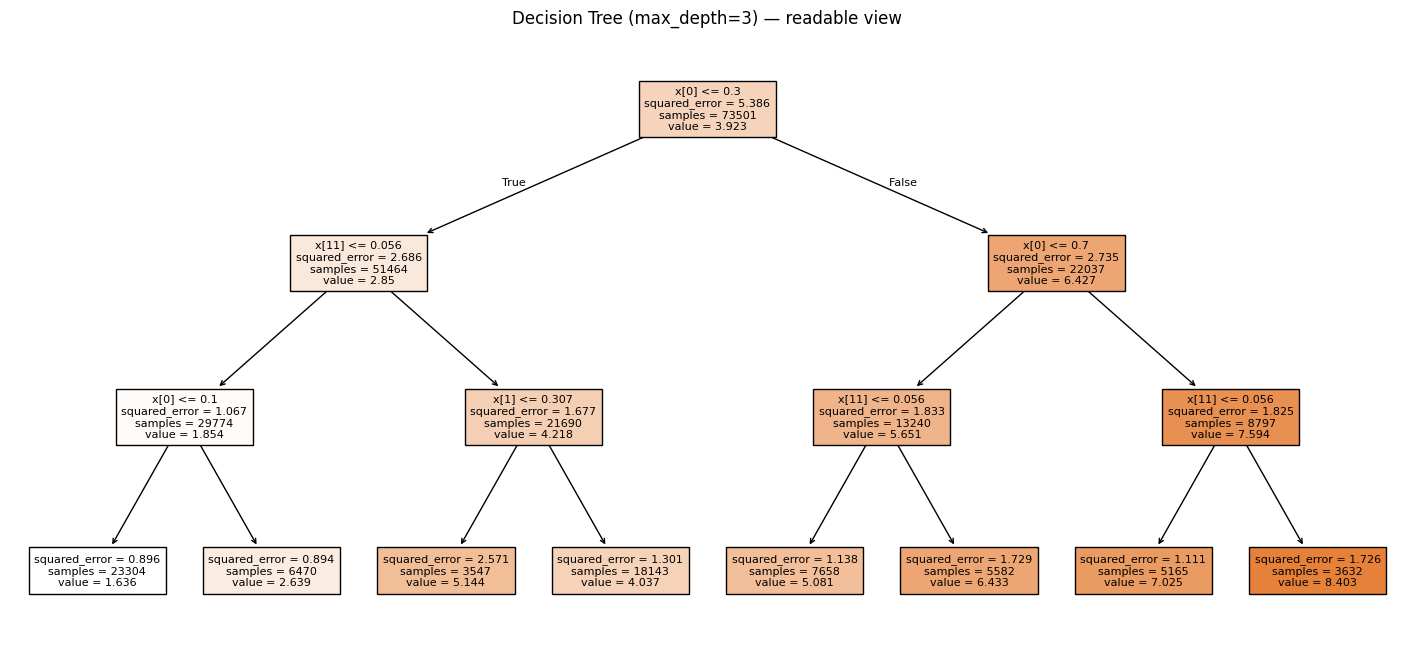

In [ ]:
from sklearn.tree import plot_tree

# Train a shallow tree just for visualization
viz_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("tree", DecisionTreeRegressor(max_depth=3, random_state=42))
])

viz_model.fit(X_train, y_train)

# Extract the fitted tree from the pipeline
fitted_tree = viz_model.named_steps["tree"]

plt.figure(figsize=(18, 8))
plot_tree(fitted_tree, filled=True, max_depth=3, fontsize=8)
plt.title("Decision Tree (max_depth=3) — readable view")
plt.show()

# ***Feature importance (what matters most?)***

In [ ]:
# Get the fitted parts
pre = model.named_steps["preprocess"]
tree_fitted = model.named_steps["tree"]

# AUTOMATICALLY extract feature names
# This function guarantees the names match the model input exactly
all_feature_names = pre.get_feature_names_out()

# Clean up the names (Optional)
clean_names = [name.split('__')[-1].replace("_Normalized","") for name in all_feature_names]

# Match names to their importance scores
importances = tree_fitted.feature_importances_
imp = pd.Series(importances, index=clean_names).sort_values(ascending=False)

# Display the top 10 factors
print("--- Top 10 Most Important Factors ---")
print(imp.head(10))

--- Top 10 Most Important Factors ---
rcount               0.585183
comorbidity_count    0.211000
hematocrit           0.033633
glucose              0.026832
sodium               0.025686
creatinine           0.025578
pulse                0.024250
respiration          0.022565
neutrophils          0.014713
bloodureanitro       0.009254
dtype: float64


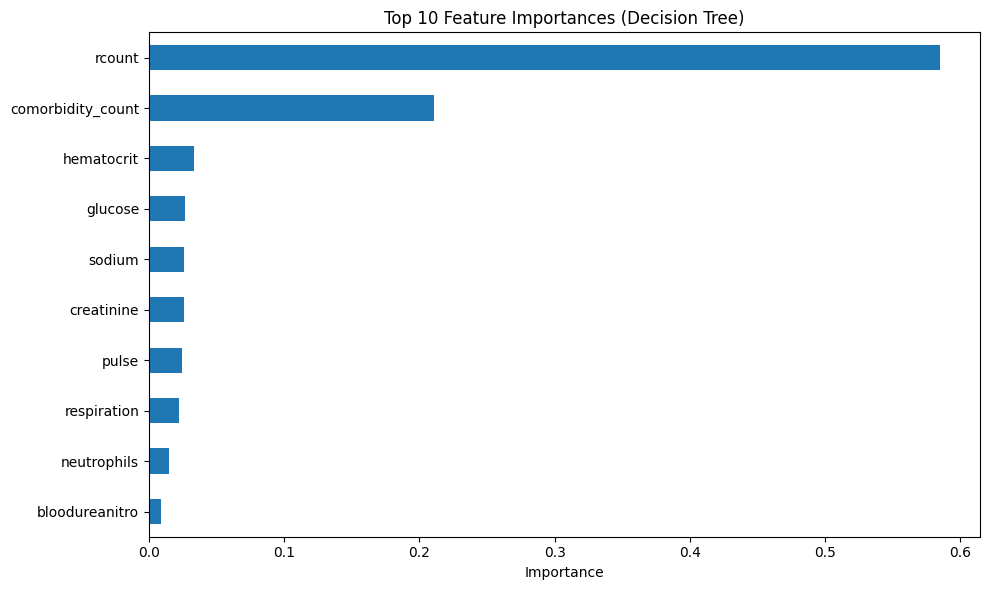

In [ ]:
# Plot top 10 importances
topk = 10
plt.figure(figsize=(10, 6))
imp.head(topk).iloc[::-1].plot(kind="barh")
plt.title("Top 10 Feature Importances (Decision Tree)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# ***Overfitting demo: depth vs train/test performance***

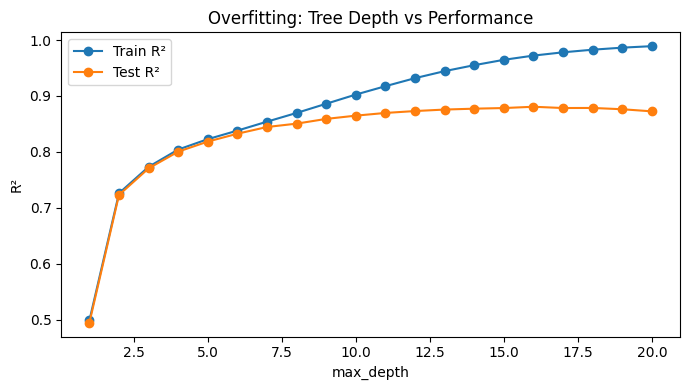

Best test R² depth (approx): 16  with test R² = 0.880664019349304


In [ ]:
depths = list(range(1, 21))
train_r2 = []
test_r2 = []

for d in depths:
    m = Pipeline(steps=[
        ("preprocess", preprocess),
        ("tree", DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    m.fit(X_train, y_train)
    train_r2.append(m.score(X_train, y_train))
    test_r2.append(m.score(X_test, y_test))

plt.figure(figsize=(7, 4))
plt.plot(depths, train_r2, marker="o", label="Train R²")
plt.plot(depths, test_r2, marker="o", label="Test R²")
plt.xlabel("max_depth")
plt.ylabel("R²")
plt.title("Overfitting: Tree Depth vs Performance")
plt.legend()
plt.tight_layout()
plt.show()

best_depth = depths[int(np.argmax(test_r2))]
print("Best test R² depth (approx):", best_depth, " with test R² =", max(test_r2))

# ***Hyperparameter tuning (GridSearchCV)***

In [ ]:
from sklearn.model_selection import GridSearchCV

# param_grid based on findings just now
param_grid = {
    "tree__max_depth": [3, 5, 10, 15, 20, 25, None], # Added 20 and others nearby
    "tree__min_samples_leaf": [1, 5, 10, 20, 50],
    "tree__min_samples_split": [2, 10, 20, 50, 100],
}

grid = GridSearchCV(
    model,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best params found:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

Fitting 3 folds for each of 175 candidates, totalling 525 fits
Best params found: {'tree__max_depth': None, 'tree__min_samples_leaf': 5, 'tree__min_samples_split': 50}
Best CV RMSE: 0.7386838568138856


In [ ]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

mae_b = mean_absolute_error(y_test, y_pred_best)
rmse_b = mean_squared_error(y_test, y_pred_best) #, squared=False)
r2_b = r2_score(y_test, y_pred_best)

print("Tuned Decision Tree (Test)")
print("MAE :", round(mae_b, 2))
print("RMSE:", round(rmse_b, 2))
print("R^2 :", round(r2_b, 4))

Tuned Decision Tree (Test)
MAE : 0.42
RMSE: 0.52
R^2 : 0.9046



# ***Prediction vs Actual plot***

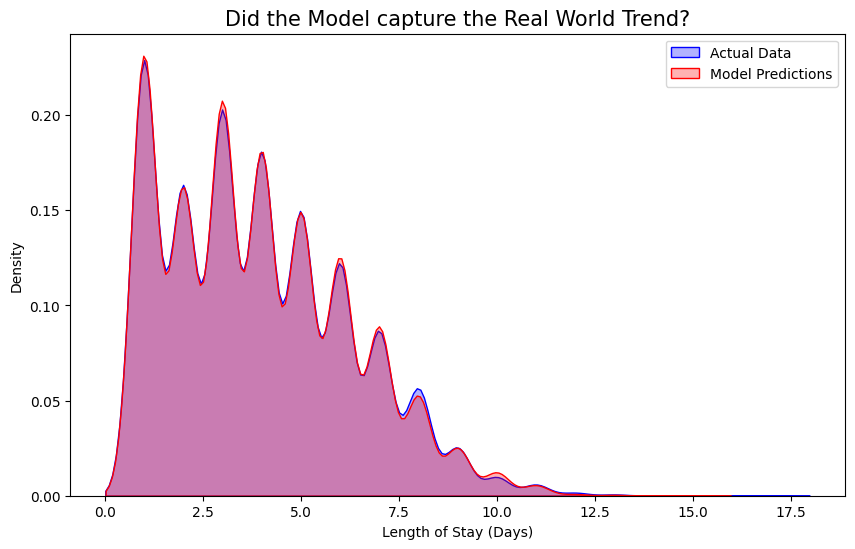

In [ ]:
plt.figure(figsize=(10, 6))

# Plot Actual Distribution
sns.kdeplot(y_test, label='Actual Data', color='blue', fill=True, alpha=0.3)

# Plot Predicted Distribution
sns.kdeplot(y_pred, label='Model Predictions', color='red', fill=True, alpha=0.3)

plt.title("Did the Model capture the Real World Trend?", fontsize=15)
plt.xlabel("Length of Stay (Days)")
plt.legend()
plt.show()